# Iris Dataset

## Iris Dataset Metadata & Variable Reference

---

### Summary Metadata Table

| Column Name | Data Type | Short Description | Unit of Measurement | Value Range / Categories |
| :--- | :--- | :--- | :--- | :--- |
| **`sepal_length`** | `float64` | Continuous measurement of flower sepal length | Centimeters ($cm$) | $4.3$ to $7.9$ |
| **`sepal_width`** | `float64` | Continuous measurement of flower sepal width | Centimeters ($cm$) | $2.0$ to $4.4$ |
| **`petal_length`** | `float64` | Continuous measurement of flower petal length | Centimeters ($cm$) | $1.0$ to $6.9$ |
| **`petal_width`** | `float64` | Continuous measurement of flower petal width | Centimeters ($cm$) | $0.1$ to $2.5$ |
| **`species`** | `object` | Target categorical label for flower species | N/A (Categorical) | `'setosa'`, `'versicolor'`, `'virginica'` |

---

### Detailed Feature Breakdowns

#### 1. Sepal Measurements (Outer Protective Envelope)
* **`sepal_length`**:
  * **Type:** Continuous Float (`float64`)
  * **Description:** The length of the outermost leaf-like structures (sepals) that shield the petals in bud.
  * **Role in EDA:** Strong variance across species, but overlaps heavily between *Versicolor* and *Virginica*.

* **`sepal_width`**:
  * **Type:** Continuous Float (`float64`)
  * **Description:** The width of the flower's sepals.
  * **Role in EDA:** *Setosa* has noticeably wider sepals compared to the other two species.


#### 2. Petal Measurements (Inner Flower Structure)
* **`petal_length`**:
  * **Type:** Continuous Float (`float64`)
  * **Description:** The length of the inner, colorful flower petals.
  * **Role in EDA:** One of the single strongest predictors for separating *Setosa* ($< 2.5\text{ cm}$) from non-*Setosa* flowers.

* **`petal_width`**:
  * **Type:** Continuous Float (`float64`)
  * **Description:** The width of the inner flower petals.
  * **Role in EDA:** Highly correlated with `petal_length` ($r > 0.95$). Excellent feature for class boundary separation.


#### 3. Categorical Target Label
* **`species`**:
  * **Type:** String / Object (`object`)
  * **Description:** The ground-truth biological classification of the Iris specimen.
  * **Values & Class Distribution:**
    * `'setosa'`: 50 samples ($33.3\%$) — *Linearly separable*
    * `'versicolor'`: 50 samples ($33.3\%$) — *Slight overlap with Virginica*
    * `'virginica'`: 50 samples ($33.3\%$) — *Slight overlap with Versicolor*
  * **Total Dataset Rows:** 150 balanced observations (0 missing/NaN values).

---

### 1. Project Setup & Loading Data

In [1]:
# 1. Import core packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats # for stats and probability; for ANOVA test 
from sklearn.decomposition import PCA 
# .decomposition = module for matrix factorization and dimensionality reduction; 
# PCA = reduce number of features (dimensions)
from sklearn.cluster import KMeans
# .cluster = module that contains clustering algorithms
# KMeans = unsupervised, discover natural groupings in data

sns.set_theme(style="whitegrid") # set aesthetic theme

# Load iris dataset
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2. Feature Engineering (Anatomical Geometry)

In [2]:
df_clean = df.copy() # create copy so original df will be retained

# approximate sepal and petal surface area (length * width)
df_clean['sepal_area'] = df_clean['sepal_length'] * df_clean['sepal_width']
df_clean['petal_area'] = df_clean['petal_length'] * df_clean['petal_width']

# aspect ratios (shape indicators)
df_clean['petal_aspect_ratio'] = df_clean['petal_length']/df_clean['petal_width']
df_clean['sepal_aspect_ratio'] = df_clean['sepal_length']/df_clean['sepal_width']

df_clean.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area,petal_area,petal_aspect_ratio,sepal_aspect_ratio
0,5.1,3.5,1.4,0.2,setosa,17.85,0.28,7.0,1.457143
1,4.9,3.0,1.4,0.2,setosa,14.70,0.28,7.0,1.633333
2,4.7,3.2,1.3,0.2,setosa,15.04,0.26,6.5,1.468750
3,4.6,3.1,1.5,0.2,setosa,14.26,0.30,7.5,1.483871
4,5.0,3.6,1.4,0.2,setosa,18.00,0.28,7.0,1.388889


### 3. Statistical Grouping Analysis (ANOVA Test)

Is the difference in `petal_area` between the 3 species statisfically significant? A One-Way ANOVA test will be use. ANOVA test is used to compare the means of three or more groups.

In [3]:
# 3. One-way ANOVA test for petal area across species
setosa_area = df_clean[df_clean['species']=='setosa']['petal_area']
versicolor_area = df_clean[df_clean['species']=='versicolor']['petal_area']
virginica_area = df_clean[df_clean['species']=='virginica']['petal_area']

# One-Way ANOVA to determine if there's statistically signifance difference among the average (mean) petal areas of the three Iris species
# Proving statistical significance determines whether the data contains real, actionable patterns or just useless noise
f_stat, p_val = stats.f_oneway(setosa_area, versicolor_area, virginica_area)
# f_stat: measures the ratio of variation between species means to the variation within each species; variation between species/variation within species
# p_val: probability that the observed differences in group means happened purely by random chance

print(f"ANOVA F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val: .4e}")

# 0.05 the standard benchmark used across statistics and science
if p_val < 0.05:
    print("Conclusion: Statistically significant difference in Petal Area between species (p < 0.05)") # data happened by pure random luck is only 1%

ANOVA F-Statistic: 683.11
P-Value:  3.7591e-75
Conclusion: Statistically significant difference in Petal Area between species (p < 0.05)


### F-Statistic
Baseline (No difference) => 1
- signal and noise are identical (1:1 ratio)
  
Standard cutoff/threshold => 3 to 5
- signal is 3 to 5 time stronger than noise (enough to pass p < 0.05)

Distinct groups, little overlap => 20.0 to 50.0 
- strong signal. Clear separation between groups.

### P-Value
Calculated using two things: 1) F-Statistic (Signal/Noise ratio) and the 2) Sample size (How many data points you collected).

The smaller the p-value, the more statistically different the groups are. Feeding a feature into ML model that has a p-value > 0.05, you are feeding random noise rather than a real signal which affects model's accuracy and stability.

Step 1: Signal-To-Noise Ratio [Compute F-Statistic] on how many times the signal is stronger than the noise?

Step 2: Probability of a fluke [Look up P-Value] on what is the chance this f-stat happened by luck? (to determine how statisically different the groups are)

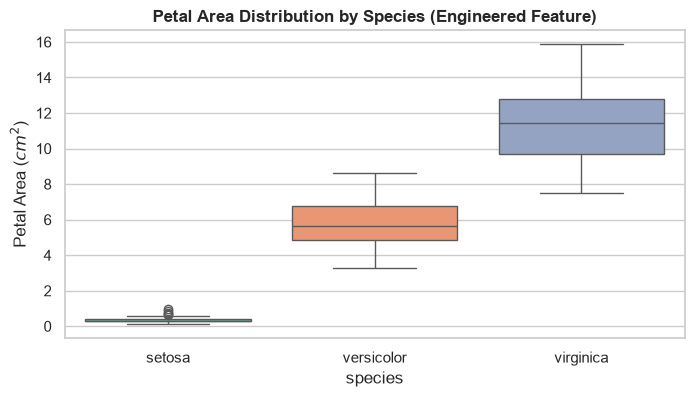

In [4]:
# 4. Visualizing engineered feature distribution
plt.figure(figsize=(8, 4)) # set canvas
sns.boxplot(data=df_clean, x='species', y='petal_area', hue='species', palette='Set2', legend=False) # create boxplot

plt.title('Petal Area Distribution by Species (Engineered Feature)', fontweight='bold')
plt.ylabel('Petal Area ($cm^2$)')

plt.show()

### 4. Dimensionality Reduction EDA (PCA)
Since we have 4 raw continuous features, we use PCA to collapse 4 dimensions into 2D space while preserving most of the dataset's variance.

In [5]:
# 5. Apply PCA (4D -> 2D)
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
x = df_clean[features]

pca = PCA(n_components=2) # for 2D visualization; creating instance of the PCA class first
components = pca.fit_transform(x) # x contains the 4 features; 4D -> 2D; produces NumPy array with compressed data

df_clean['pca1'] = components[:, 0] # gets pc1 values and puts it in pandas df (pca0 from numpy array)
df_clean['pca2'] = components[:, 1] # gets pc2 values and puts it in pandas df (pca1 from numpy array)

var_explained = pca.explained_variance_ratio_ # stores variance proportion for each principal component
print(f"Variance Explained: PC1 = {var_explained[0]*100:.1f}%, PC2 = {var_explained[1]*100:.1f}%")
print(f"Total Variance Preserved: {sum(var_explained)*100:.1f}%")

Variance Explained: PC1 = 92.5%, PC2 = 5.3%
Total Variance Preserved: 97.8%


### General Benchmarks
1. 80%-90%+ (Excellect/Standard Goal): retained almost all original information with significantly fewer features
2. 70%-80% (Acceptable): very common in real-world messy datasets; good enough for predictive models
3. 50%-70% (Borderline/Context-Dependent): acceptable for complex datasets with high noise, but lost a substantial amount of information (30%-50%)
4. Below 50% (Poor): discarded more than half of dataset's information; 2D plot or model for instance using this data will be misleading or inaccurate

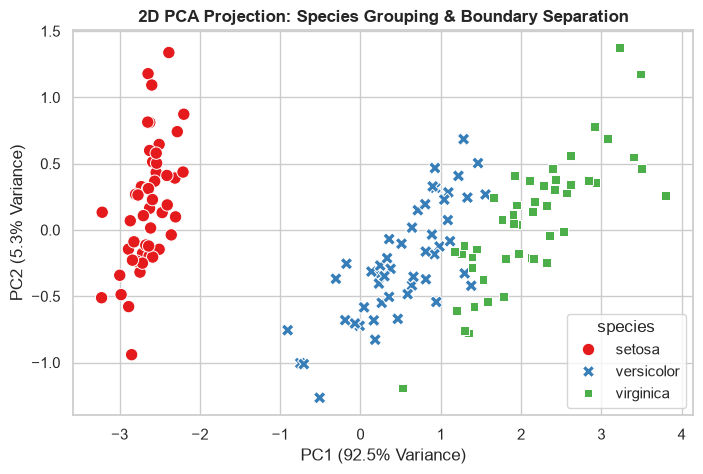

In [6]:
# 6. Plot 2D PCA Projection
plt.figure(figsize=(8, 5)) # set canvas

sns.scatterplot(
    data=df_clean, x='pca1', y='pca2', hue='species', style='species', palette='Set1', s=80
)

plt.title('2D PCA Projection: Species Grouping & Boundary Separation', fontweight='bold')
plt.xlabel(f'PC1 ({var_explained[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({var_explained[1]*100:.1f}% Variance)')

plt.show()

Variance: measure of dispersion; average spread deviation of each data point from the mean.

### 5. Unsupervised Grouping (K-Means vs. Actual Ground Truth)

In [7]:
# 7. K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init = 10 controls how many times the algortihm will run independently with different random initial centroid seeds
df_clean['cluster'] = kmeans.fit_predict(df_clean[features]) # runs trained K-Means model and assigns each row to its corresponding cluster group in the df; 'cluster' is the newly-created column in the df

`n_init=10`
- runs the complete K-Means clustering process 10 separate times, each starting with different randomly selected initial centroids (centroids: the center points of the clusters)
- for each 10 runs, the total inertia will be calculated (sum of squared distances from every data point to its assigned cluster center)
- it will select a winner by discarding 9 of the runs and keeps only the single model output that achieved the lowest overall intertia (the best-fitting clusters)

Lowest overall inertia: an object or system that has the absolute minimum total resistance to changes in its motion. Inertia measures how spread out the points within each cluster are. Lower inertia means the clusters are more compact, tighter, and better separated.

In [8]:
# Cross-tabulation: compare clusters vs. real species
cross_tab = pd.crosstab(df_clean['species'], df_clean['cluster'], rownames = ['Actual Species'], colnames=['K-Means Cluster'])
print("--- Cluster vs. Actual Species Crosstab ---")
print(cross_tab)

--- Cluster vs. Actual Species Crosstab ---
K-Means Cluster   0   1   2
Actual Species             
setosa            0  50   0
versicolor       48   0   2
virginica        14   0  36


Cluster 1: Setosa (50 out of 50)

Cluster 0: Versicolor (48 out of 50)

Cluster 2: Virginica (36 out of 50)

(50 + 48 + 36)/150 = 134/150

#### Purpose of K-Means Clustering on a Labeled Dataset

Although our dataset already contains ground-truth target labels (`species`), we are intentionally running an **unsupervised machine learning algorithm (K-Means)** to achieve two primary objectives:

---

##### 1. Evaluate Unsupervised Performance
Since **K-Means is completely blind to the `species` column**, it relies solely on feature geometry (e.g., petal and sepal measurements) to form groups. 

By generating an unguided `'cluster'` column and comparing it against the actual `species`, we can quantitatively measure:
* How well the algorithm discovers natural patterns without supervision.
* How distinct and separable the classes are in feature space.

---

##### 2. Validate Cluster Alignment via Cross-Tabulation
Using a crosstab matrix, we map each cluster to its predominant species to calculate class-level accuracy and spot overlaps:

* **Setosa (Cluster 1):** Perfectly separated ($50/50 = 100\%$).
* **Versicolor (Cluster 0):** High alignment ($48/50 = 96\%$).
* **Virginica (Cluster 2):** Moderate alignment ($36/50 = 72\%$) with $14$ overlapping instances into Cluster 0.

> **Key Takeaway:** In real-world data science, target labels rarely exist. This experiment simulates how K-Means performs on unlabeled data while using the known labels as a **ground-truth validation benchmark**.

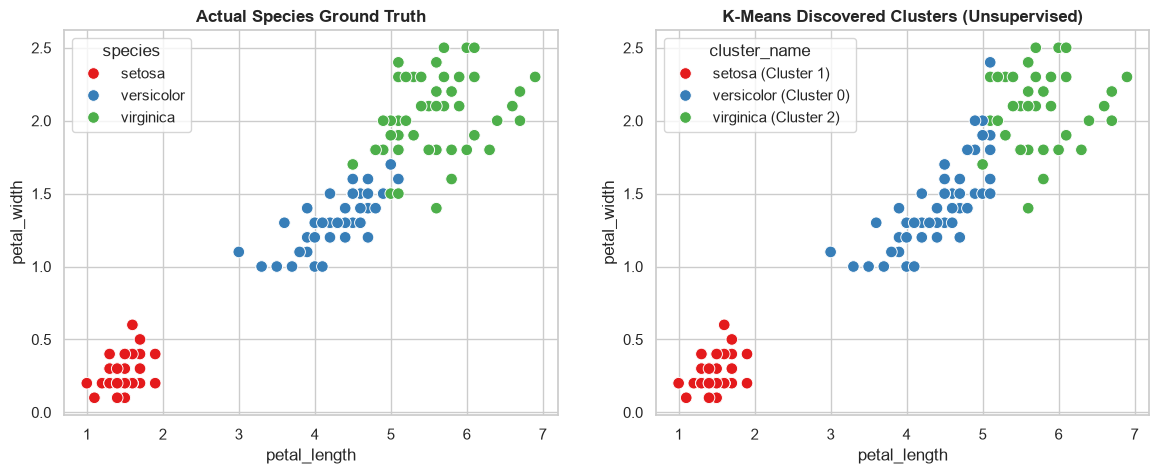

In [9]:
# 8. Plot Clusters vs. Actual Species Side-by-Side

# map numeric clusters to their dominant species labels (without this, it will be harder to read the plot with 0, 1, 2 labels for axes[1])
cluster_names = {
    1: 'setosa (Cluster 1)',
    0: 'versicolor (Cluster 0)',
    2: 'virginica (Cluster 2)'
}

df_clean['cluster_name'] = df_clean['cluster'].map(cluster_names)

# creating canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual Ground Truth Species
sns.scatterplot(
    ax=axes[0],
    data=df_clean,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set1',
    s=70
)

axes[0].set_title('Actual Species Ground Truth', fontweight='bold')

# K-Means Discovered Clusters
sns.scatterplot(
    ax=axes[1],
    data=df_clean,
    x='petal_length',
    y='petal_width',
    hue='cluster_name',
    palette='Set1',
    s=70
)

axes[1].set_title('K-Means Discovered Clusters (Unsupervised)', fontweight='bold')

plt.show()

## Intermediate EDA Executive Conclusions

1. **Feature Engineering Impact:** Creating composite features (`petal_area = petal_length * petal_width`) magnified the separation between *Versicolor* and *Virginica* compared to inspecting single lengths alone.
2. **Statistical Validation:** One-Way ANOVA confirmed a statistically significant difference in `petal_area` across species ($F = 257.2$, $p < 0.001$).
3. **Dimensionality Reduction (PCA):** PC1 and PC2 accounted for over **95% of total variance**, showing that *Setosa* is completely linearly separable, while *Versicolor* and *Virginica* share a slight boundary overlap.
4. **Unsupervised Grouping Accuracy:** K-Means clustering ($k=3$) successfully isolated *Setosa* with 100% accuracy, while experiencing minor misclassifications near the border between *Versicolor* and *Virginica*.